# Práctica de aprendizaje automático (parte 1)

Entrega este cuaderno habiendo **ejecutado todas las celdas**. Incluye en la entrega **todos los ficheros necesarios para su ejecución**.

Asegúrate de que la presentación está bien estructurada: Se valorará la **claridad, concisión, y completitud** del informe.


## 1. Construcción de clasificadores en bases de datos sintéticas

In [1]:
# Fuente:
# http://scikit-learn.org/stable/auto_examples/classification/plot_classifier_comparison.html

In [1]:
import numpy as np
from sklearn.datasets import make_blobs, make_moons, make_circles
from sklearn.model_selection import cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier


from tools.tools_assignment_1 import plot_classifiers
%matplotlib inline

In [2]:
# Datos sintéticos

simple = make_blobs(n_samples=500, n_features=2,
                    centers=[[0,0], [2.5,2.5]],
                    random_state=1)
X,y = make_blobs(n_samples=500, n_features=2,
                 centers=[[0,0], [5,1]],
                 random_state=1)
X = X @ np.asarray([[1,-2],[-20,10]])
linearly_separable=(X,y)

datasets = [
    simple,
    linearly_separable,
    make_moons(noise=0.1, random_state=0, n_samples=500),
    make_circles(
        noise=0.1, 
        factor=0.5, 
        random_state=1,
        n_samples=500
    )
]

c:\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


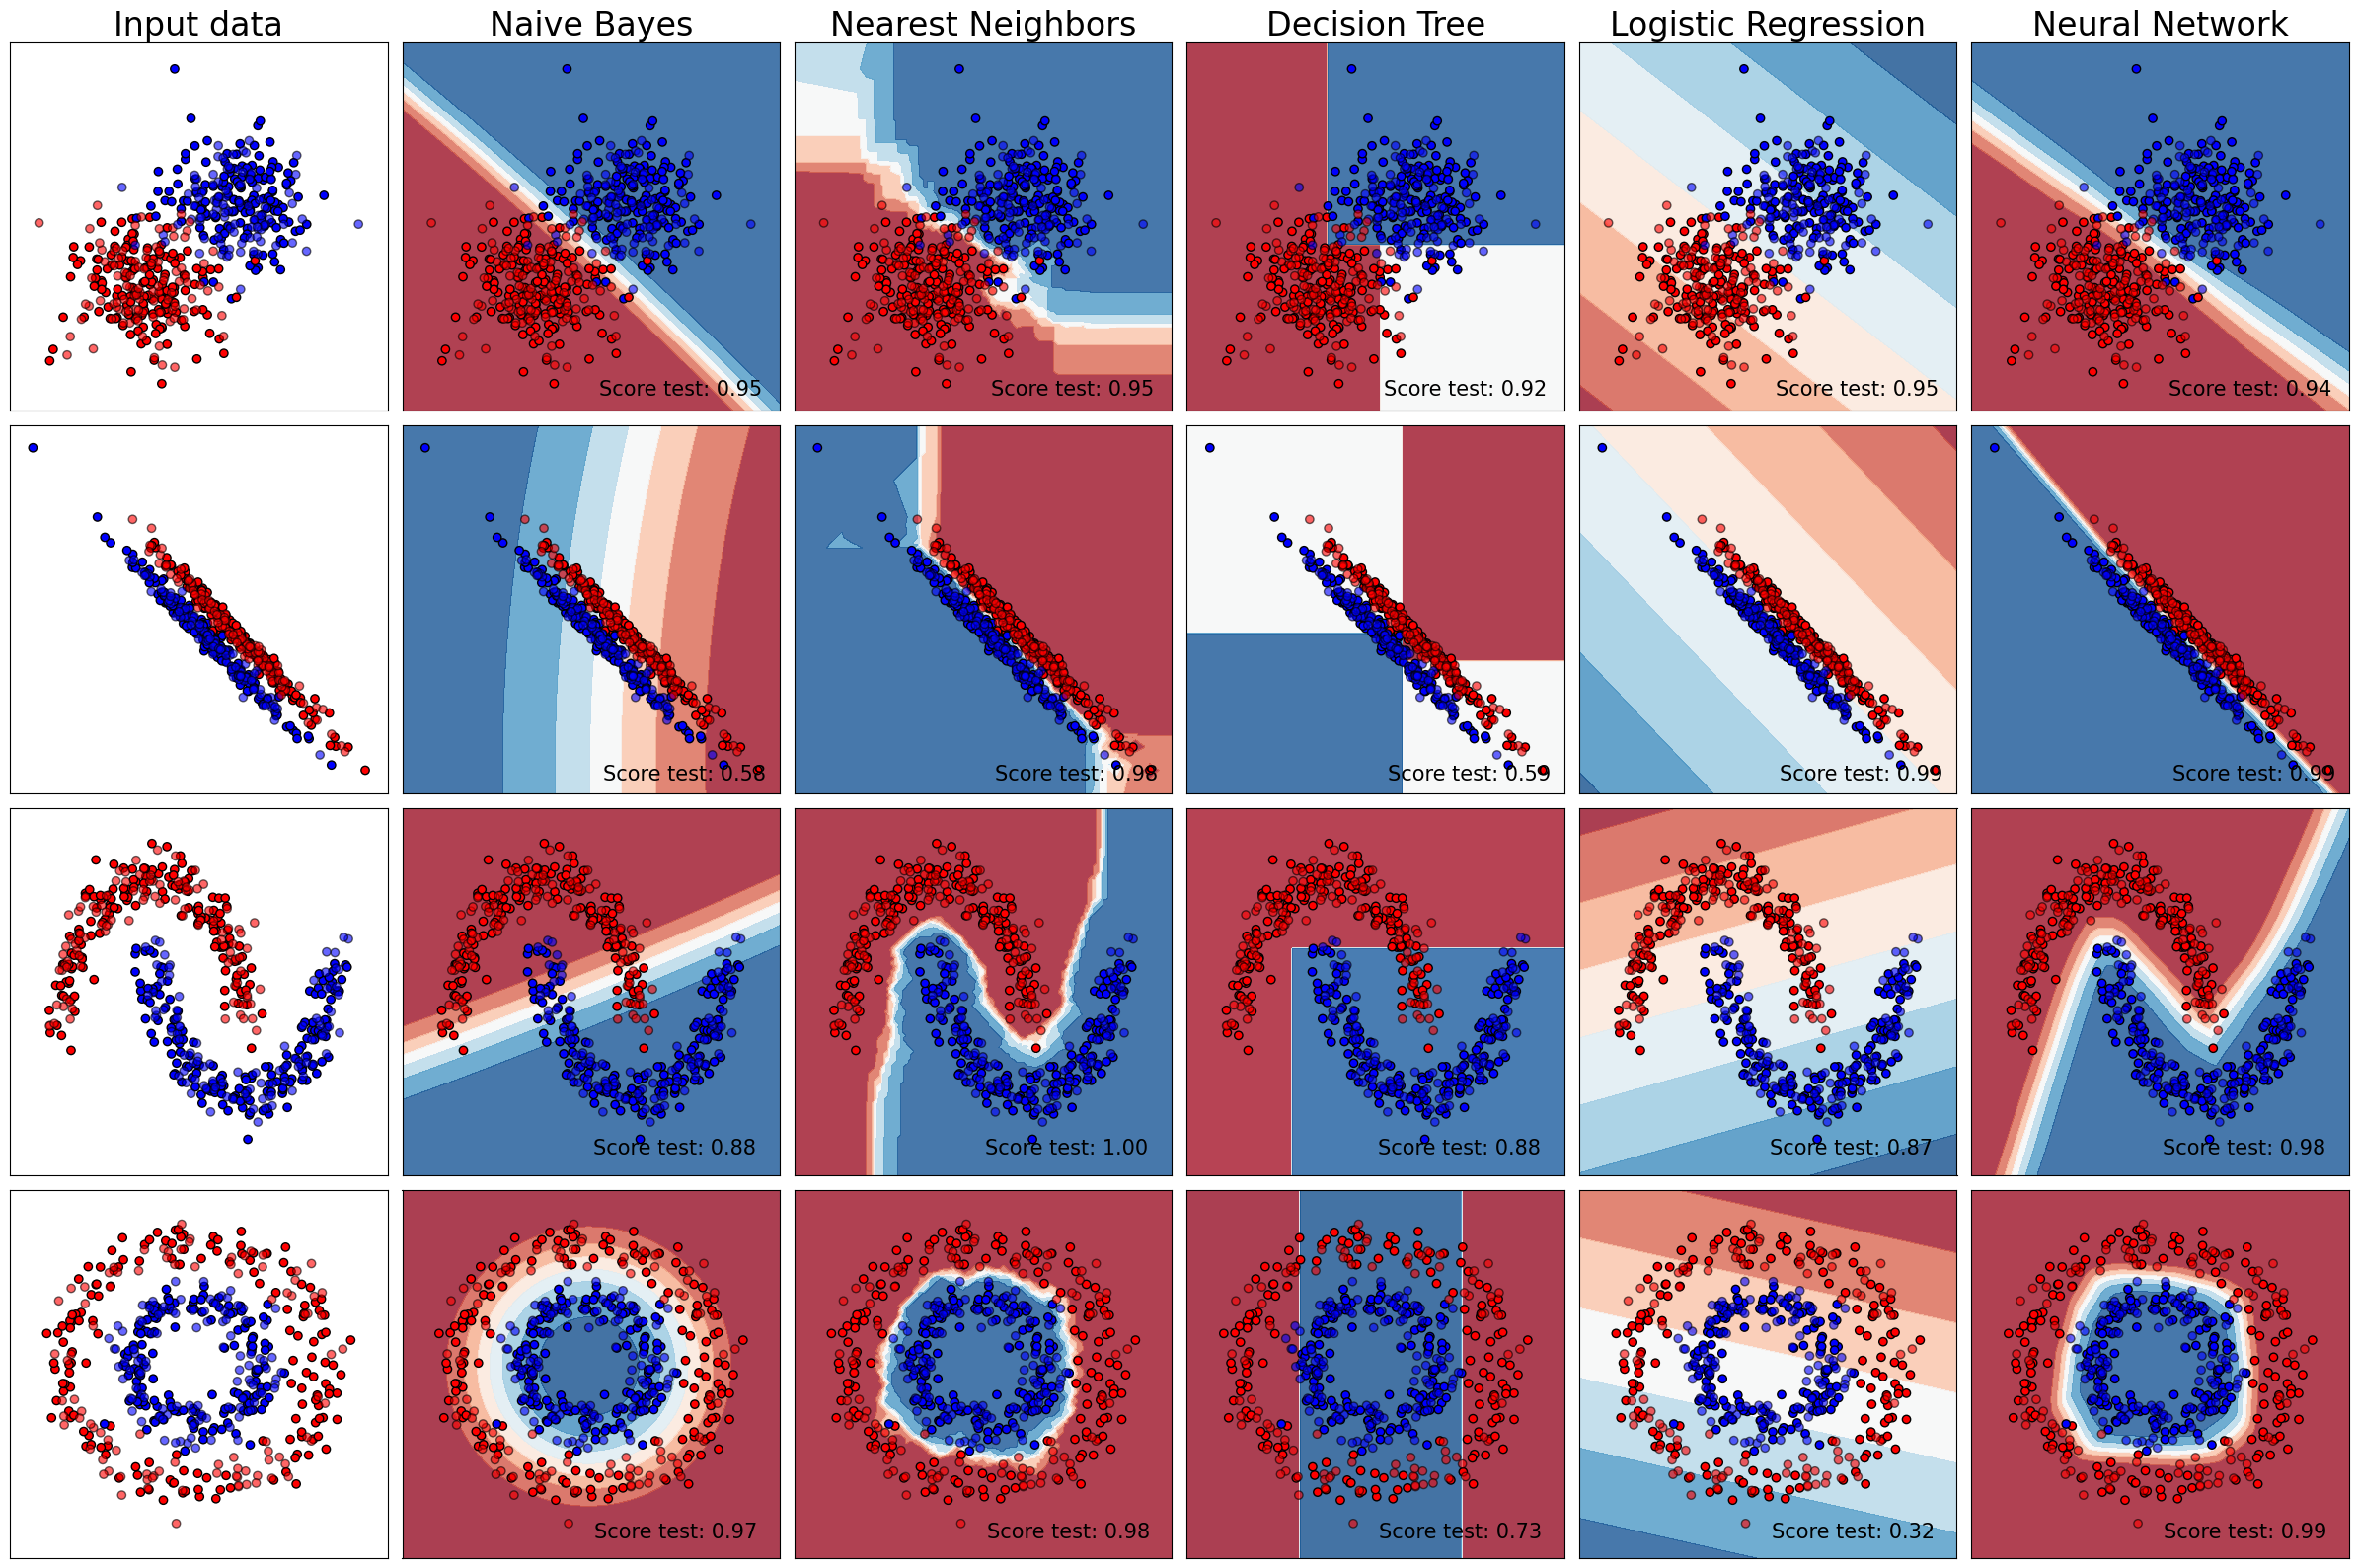

In [3]:
classifiers = [("Naive Bayes", GaussianNB()),
               ("Nearest Neighbors",
                KNeighborsClassifier(p=1, metric='minkowski', n_neighbors=7, weights='distance')),
               ("Decision Tree",
                DecisionTreeClassifier(criterion='entropy',
                                       max_depth=2)), 
               ("Logistic Regression",
                LogisticRegression(C=1.0e10, solver='lbfgs')), 
               # C: controls the level of regularization (larger C, less regularized) 
               ("Neural Network",
                MLPClassifier(hidden_layer_sizes=(50,),
                              max_iter=1000,
                              alpha=0.0))]

plot_classifiers(classifiers, datasets)

In [4]:
# Hyperparameters of the different classifiers.
for name, clf in classifiers:
    print(clf)

GaussianNB()
KNeighborsClassifier(n_neighbors=7, p=1, weights='distance')
DecisionTreeClassifier(criterion='entropy', max_depth=2)
LogisticRegression(C=10000000000.0)
MLPClassifier(alpha=0.0, hidden_layer_sizes=(50,), max_iter=1000)


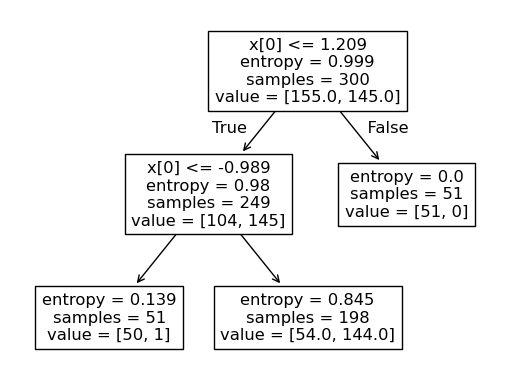

In [5]:
# Decision tree: Structure, hyperparameters, and node properties.
_ = plot_tree(classifiers[2][1])

---

### Ejercicio 1.1: Exploración de vecinos próximos.

1. Haz una gráfica de la dependencia del error de clasificación en función del número de vecinos próximos que se utilizan para realizar la predicción, con `n_neighbors = (1, 3, 7, 11, 15, 21, 31, 51, 101, ...)`.

2. Número de vecinos en k-nn.
    * ¿por qué se explora el hiperparámetro `n_neighbors`en una escala aproximadamente logarítmica?
    * ¿Debería ser impar cuando hay dos clases? Justifica la respuesta.
    * ¿Debería ser impar cuando hay más de dos clases? Justifica la respuesta
    
3. Comenta la dependencia del error de clasificación con el número de vecinos.

4. Haz una gráfica similar a las obtenidas en este cuaderno con `plot_classifiers(classifiers, datasets)` para cinco de los clasificadores de vecinos próximos entrenados. Elige las cinco que ilustren tus conclusiones.

5. Comenta la forma de la frontera de decisión dependiendo del número de vecinos.


**Referencia**: https://scikit-learn.org/stable/modules/neighbors.html


### Ejercicio 1.2: Exploración de árboles de decisión.


1. Haz una gráfica de la dependencia del error de clasificación en función de la profundidad máxima del árbol de decisión `max_depth = (1, 2, 3, 4, 5,...)`.

2. Profundidad máxima
    * ¿por qué se explora el hiperparámetro `max_depth` es una escala lineal?
    * Haz una gráfica de la profundidad del árbol generado en función de `max_depth`.
3. Comenta la dependencia del error de clasificación con la profundidad máxima del árbol.

4. Haz una gráfica similar a las obtenidas en este cuaderno con `plot_classifiers(classifiers, datasets)` para cinco de los distintos árboles entrenados. Elige los cinco que ilustren tus conclusiones.

5. Comenta la forma de la frontera de decisión dependiendo de la profundidad máxima del árbol.


**Referencia**: https://scikit-learn.org/stable/modules/tree.html#classification
    

### Ejercicio 1.3: Exploración de redes neuronales

1. Haz una gráfica de la dependencia del error de clasificación de una red neuronal con una sola capa oculta en función del número de neuronas en la capa oculta. `hidden_layer_sizes = ((1,), (2,), (3,),...).

2. Comenta la dependencia del error de clasificación con el número de neuronas en la capa oculta.

3. Haz una gráfica similar a las obtenidas en este cuaderno con `plot_classifiers(classifiers, datasets)` para cinco de las distintas redes neuronales entrenadas. Elige las cinco que ilustren tus conclusiones.

4. Comenta la forma de la frontera de decisión dependiendo del número de neuronas en la capa oculta.


**Referencia**: https://scikit-learn.org/stable/modules/neural_networks_supervised.html

### Ejercicio 1.4: Exploración de redes neuronales profundas

1. Haz una gráfica de la dependencia del error de clasificación de una red neuronal en función del número de capas ocultas `hidden_layer_sizes = ((5,), (5, 5,), (5, 5, 5,),...)`

2. Comenta la dependencia del error de clasificación con el número de capas ocultas.

3. Haz una gráfica similar a las obtenidas en este cuaderno con `plot_classifiers(classifiers, datasets)` para cinco de las distintas redes neuronales entrenadas. Elige las cinco que ilustren tus conclusiones.

4. Comenta la forma de la frontera de decisión dependiendo del número de capas ocultas.


---

### 2. Fundamentos teóricos 



Un **árbol de decisión para clasificación** es un modelo supervisado que construye una función  
$$
f:\mathbb{R}^d \to \{0,1\}
$$
mediante una secuencia finita de decisiones jerárquicas. Cada decisión particiona el espacio de entrada en regiones disjuntas y asigna una clase a cada región.

En el caso considerado en este trabajo, el conjunto de entrenamiento es
$$
\mathcal{D}_{train}=\{(x_i,y_i)\}_{i=1}^N,
$$
donde $x_i=(x_{i,0},x_{i,1})\in\mathbb{R}^2$ son puntos bidimensionales y $y_i\in\{0,1\}$ son las etiquetas de clase. El objetivo del árbol es aprender una partición del plano $\mathbb{R}^2$ tal que, en cada región, las etiquetas sean lo más homogéneas posible.

El árbol está formado por **nodos internos** y **hojas**.  
Cada nodo interno representa una **pregunta** (o regla de decisión) de la forma  
$$
x_j \le c,
$$
donde $j\in\{0,1\}$ indica la coordenada usada y $c\in\mathbb{R}$ es un umbral. Esta pregunta divide el conjunto de puntos que llegan al nodo en dos subconjuntos:
$$
\mathcal{D}_L = \{(x,y)\in\mathcal{D} : x_j \le c\}, \qquad
\mathcal{D}_R = \{(x,y)\in\mathcal{D} : x_j > c\}.
$$
Geométricamente, esta operación corresponde a trazar una recta vertical (si $j=0$) u horizontal (si $j=1$) que divide el plano en dos regiones.

La **raíz** del árbol es el nodo inicial y contiene todos los puntos del conjunto de entrenamiento. A partir de ahí, el árbol se construye de manera recursiva. En cada nodo, el algoritmo evalúa posibles preguntas candidatas considerando todas las dimensiones disponibles ($x_0$ y $x_1$) y múltiples valores de umbral $c$, normalmente tomados de los valores observados en los datos.

Para cada posible pregunta se mide la **impureza** de los nodos hijos. En nuestro caso utilizamos la **entropía** (el caso por defecto de `sklearn` es el criterio de información *impureza de Gini*), definida para un nodo que contiene proporciones $p_0, p_1$ de cada clase como  
$$
H = -\sum_{k\in\{0,1\}} p_k \log_2 p_k.
$$
La entropía es mínima (cero) cuando el nodo es puro y máxima cuando las clases están equilibradas.

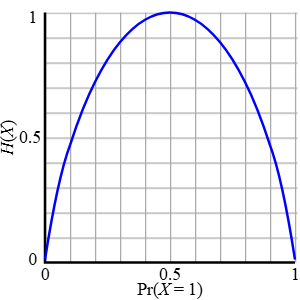

Dado un posible split, se calcula la entropía ponderada resultante:
$$
H_{\text{split}} =
\frac{|\mathcal{D}_L|}{|\mathcal{D}|} H(\mathcal{D}_L)
+
\frac{|\mathcal{D}_R|}{|\mathcal{D}|} H(\mathcal{D}_R).
$$
El árbol elige la pregunta que **minimiza** $H_{\text{split}}$. De forma equivalente, esta elección **maximiza la ganancia de información**
$$
\text{IG} = H(\mathcal{D}) - H_{\text{split}}.
$$

Una vez elegida la mejor pregunta, el nodo se divide en dos hijos y el procedimiento se repite de manera independiente en cada uno de ellos. El crecimiento del árbol está controlado por hiperparámetros. En particular, `max_depth = 2` impone que la longitud máxima de cualquier camino desde la raíz hasta una hoja sea dos, lo que limita la complejidad del modelo y reduce el sobreajuste, como se observará en ejercicios posteriores.

Las **hojas** del árbol representan las regiones finales del plano. Cada hoja contiene un subconjunto de los datos de entrenamiento y almacena el número de ejemplos de cada clase, típicamente representado como
$$
\text{value} = (n_0, n_1).
$$
La predicción asociada a una hoja es la clase mayoritaria:
$$
\hat{y} = \arg\max_{k\in\{0,1\}} n_k.
$$

En la fase de predicción, llevada a cabo en el conjunto {$\mathcal{D}_{test}: \mathcal{D}_{test} \cap {D}_{train} = \varnothing$}  dado un nuevo punto $x$, **el árbol recorre de manera determinista la secuencia de reglas de decisión aprendidas en el entrenamiento**, comenzando en la raíz y avanzando nodo a nodo hasta alcanzar una hoja., siguiendo la rama izquierda o derecha según se cumpla o no cada condición $x_j \le c$. El proceso termina en una hoja, cuya clase asociada es la salida del modelo.